# Grid Search Multi-Modelo: Hernia Hiatal en RX Frontal

Este notebook extiende la lógica de los notebooks de entrenamiento individuales para ejecutar una **búsqueda en grilla** sobre:

- `resnet18`
- `densenet121`
- `efficientnetb0`

Cada combinación de hiperparámetros se registra como un run independiente en **MLflow**.

<a id="etapa-1"></a>
## Etapa 1: Configuración y entorno

In [17]:
# Etapa 1) Configuración clara y mínima
import random
import os
import json
import sys
import socket
import subprocess
import time
from dataclasses import dataclass
from datetime import datetime
from itertools import product
from pathlib import Path
from urllib.parse import urlparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as T
from torch import nn
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torchvision.models import (
    resnet18, ResNet18_Weights,
    densenet121, DenseNet121_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
)

from PIL import Image, ImageOps

import mlflow

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, f1_score

print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('mlflow:', mlflow.__version__)

RAIZ = Path.cwd().resolve()
if RAIZ.name == 'jupyter':
    RAIZ = RAIZ.parent

# Soporta ejecución desde la raíz del curso o desde la raíz del microproyecto.
RUTA_IMAGENES = RAIZ / 'data' / 'images'
RUTA_SALIDA = RAIZ / 'outputs' / 'hiatal_grid_search'
RUTA_SALIDA.mkdir(parents=True, exist_ok=True)

SEMILLA = 42
CPU_CORES = os.cpu_count() or 8
TAM_IMAGEN = 512
CACHE_IMAGENES_RAM = False
N_SPLITS = 2
PACIENCIA = 5
USAR_PREENTRENADO = False
FACTOR_MUESTRAS_ENTRENAMIENTO_POR_EPOCA = 1

# Modo rápido para ejecutar en notebook sin esperar horas.
MODO_RAPIDO = False

# Grid de hiperparámetros (cada combinación = 1 prueba MLflow).
ARQUITECTURAS = ['resnet18', 'densenet121', 'efficientnetb0']
GRID_LR = [1e-5] if MODO_RAPIDO else [1e-3, 3e-4, 1e-4, 5e-5]
GRID_DROPOUT = [0.25] if MODO_RAPIDO else [0.2, 0.3, 0.4]
GRID_WEIGHT_DECAY = [1e-3] if MODO_RAPIDO else [1e-3, 1e-4]
GRID_EPOCAS = [1] if MODO_RAPIDO else [3]
GRID_EPOCAS_CONGELADAS = [2] #[0] if MODO_RAPIDO else [2]

# MLflow solo en modo servidor
MLFLOW_TRACKING_URI = 'http://localhost:8050'
MLFLOW_EXPERIMENTO = 'hernia-hiatal-grid-search'
PREFIJO_RUN = f"grid_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.environ['MLFLOW_SUPPRESS_PRINTING_URL_TO_STDOUT'] = 'true'

# Autoarranque de servidor MLflow local
MLFLOW_AUTO_INICIAR_SERVIDOR_LOCAL = True
MLFLOW_TIMEOUT_CONEXION_SEGUNDOS = 1.5
MLFLOW_SERVIDOR_LOCAL_HOST = '127.0.0.1'
MLFLOW_SERVIDOR_LOCAL_PUERTO = 8050
MLFLOW_SERVIDOR_LOCAL_ALLOWED_HOSTS = f'localhost:{MLFLOW_SERVIDOR_LOCAL_PUERTO},127.0.0.1:{MLFLOW_SERVIDOR_LOCAL_PUERTO}'
MLFLOW_SERVIDOR_LOCAL_BACKEND_DB = RUTA_SALIDA / 'mlflow_server_backend.db'
MLFLOW_SERVIDOR_LOCAL_ARTIFACTS = RUTA_SALIDA / 'mlflow_server_artifacts'
MLFLOW_SERVIDOR_LOCAL_LOG = RUTA_SALIDA / 'mlflow_server_local.log'

DISPOSITIVO = torch.device('cuda') if torch.cuda.is_available() else (
    torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
)
USAR_AMP = DISPOSITIVO.type == 'cuda'

if DISPOSITIVO.type == 'cuda':
    torch.backends.cudnn.benchmark = True
    try:
        torch.backends.cuda.matmul.fp32_precision = 'tf32'
        torch.backends.cudnn.conv.fp32_precision = 'tf32'
    except Exception:
        try:
            torch.set_float32_matmul_precision('high')
        except Exception:
            pass
    TAM_BATCH = 32
else:
    TAM_BATCH = 8

# Para dataset pequeño en notebook Windows, workers altos empeoran rendimiento.
NUM_WORKERS_TRAIN = 0
NUM_WORKERS_VAL = 0
PREFETCH_FACTOR = 2
PERSISTENT_WORKERS = False
MEJORA_MINIMA_SCORE = 0.002

OPS_AUG = [
    T.RandomApply([T.ColorJitter(brightness=0.12, contrast=0.15)], p=0.35),
    T.RandomAffine(degrees=8, translate=(0.03, 0.03), scale=(0.97, 1.03)),
]

print('RAIZ:', RAIZ)
print('Datos:', RUTA_IMAGENES)
print('Salida:', RUTA_SALIDA)
print('Dispositivo:', DISPOSITIVO)
print('MLflow URI:', MLFLOW_TRACKING_URI)
print('MLflow experimento:', MLFLOW_EXPERIMENTO)
print('MODO_RAPIDO:', MODO_RAPIDO)
print('Batch:', TAM_BATCH)
print('Workers train:', NUM_WORKERS_TRAIN, '| val:', NUM_WORKERS_VAL)
print('Prefetch:', PREFETCH_FACTOR if NUM_WORKERS_TRAIN > 0 else 0, '| persistent:', PERSISTENT_WORKERS)


torch: 2.9.0+cu126
torchvision: 0.24.0+cu126
mlflow: 3.10.0
RAIZ: G:\My Drive\Educacion\U de los Andes\MAIA\IV\Proyecto - Desarrollo de Soluciones\Micro-proyecto\maia_proyecto_desarrollo_soluciones
Datos: G:\My Drive\Educacion\U de los Andes\MAIA\IV\Proyecto - Desarrollo de Soluciones\Micro-proyecto\maia_proyecto_desarrollo_soluciones\data\images
Salida: G:\My Drive\Educacion\U de los Andes\MAIA\IV\Proyecto - Desarrollo de Soluciones\Micro-proyecto\maia_proyecto_desarrollo_soluciones\outputs\hiatal_grid_search
Dispositivo: cuda
MLflow URI: http://localhost:8050
MLflow experimento: hernia-hiatal-grid-search
MODO_RAPIDO: False
Batch: 32
Workers train: 0 | val: 0
Prefetch: 0 | persistent: False


<a id="etapa-2"></a>
## Etapa 2: Utilidades de datos, modelo, entrenamiento y MLflow

In [ ]:
# Etapa 2) Utilidades del pipeline
EXTENSIONES_VALIDAS = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}
ETIQUETAS_NORMAL = {'0', 'normal', 'sano', 'healthy', 'neg', 'negative'}
MEDIA_IMAGENET = [0.485, 0.456, 0.406]
STD_IMAGENET = [0.229, 0.224, 0.225]


def fijar_semilla(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


fijar_semilla(SEMILLA)


@dataclass(frozen=True)
class Muestra:
    ruta: Path
    etiqueta: int
    id_paciente: str


class RecorteRetrocardiaco:
    def __init__(self, x1=0.2, x2=0.8, y1=0.15, y2=0.98):
        self.x1, self.x2, self.y1, self.y2 = x1, x2, y1, y2

    def __call__(self, imagen: Image.Image):
        ancho, alto = imagen.size
        return imagen.crop((int(self.x1 * ancho), int(self.y1 * alto), int(self.x2 * ancho), int(self.y2 * alto)))


class ConjuntoHiatal(Dataset):
    def __init__(self, muestras, indices, transformacion, cache_imagenes_ram=False):
        self.muestras = [muestras[i] for i in indices]
        self.transformacion = transformacion
        self.imagenes_gris_cache = None

        if cache_imagenes_ram:
            self.imagenes_gris_cache = []
            for muestra in self.muestras:
                with Image.open(muestra.ruta) as imagen:
                    imagen_gris = ImageOps.autocontrast(imagen.convert('L'))
                self.imagenes_gris_cache.append(np.array(imagen_gris, dtype=np.uint8))

    def __len__(self):
        return len(self.muestras)

    def __getitem__(self, i):
        muestra = self.muestras[i]
        if self.imagenes_gris_cache is None:
            with Image.open(muestra.ruta) as imagen:
                imagen_gris = ImageOps.autocontrast(imagen.convert('L'))
        else:
            imagen_gris = Image.fromarray(self.imagenes_gris_cache[i], mode='L')

        imagen_rgb = Image.merge('RGB', (imagen_gris, imagen_gris, imagen_gris))
        tensor_entrada = self.transformacion(imagen_rgb)
        objetivo = torch.tensor(float(muestra.etiqueta), dtype=torch.float32)
        return tensor_entrada, objetivo, str(muestra.ruta)


def construir_muestras_desde_carpetas(ruta_imagenes: Path):
    pares = []
    for carpeta_clase in sorted([p for p in ruta_imagenes.iterdir() if p.is_dir()]):
        etiqueta = 0 if carpeta_clase.name.strip().lower() in ETIQUETAS_NORMAL else 1
        for ruta_imagen in sorted(carpeta_clase.rglob('*')):
            if ruta_imagen.suffix.lower() in EXTENSIONES_VALIDAS:
                pares.append((ruta_imagen, etiqueta))

    muestras = []
    for ruta_imagen, etiqueta in pares:
        id_paciente = ruta_imagen.stem.split('_')[0]
        muestras.append(Muestra(ruta=ruta_imagen, etiqueta=int(etiqueta), id_paciente=id_paciente))
    return muestras


def construir_transformaciones(tam_imagen=320):
    ops_roi = [RecorteRetrocardiaco()]
    normalizacion = T.Normalize(mean=MEDIA_IMAGENET, std=STD_IMAGENET)

    ops_aug = OPS_AUG

    transf_train = T.Compose(ops_roi + [T.Resize((tam_imagen, tam_imagen))] + ops_aug + [T.ToTensor(), normalizacion])
    transf_val = T.Compose(ops_roi + [T.Resize((tam_imagen, tam_imagen)), T.ToTensor(), normalizacion])
    return transf_train, transf_val


def crear_modelo(nombre_modelo: str, preentrenado=True, dropout=0.25):
    nombre_modelo = nombre_modelo.lower()

    if nombre_modelo == 'resnet18':
        pesos = ResNet18_Weights.DEFAULT if preentrenado else None
        modelo = resnet18(weights=pesos)
        in_features = modelo.fc.in_features
        modelo.fc = nn.Sequential(nn.Dropout(p=float(dropout)), nn.Linear(in_features, 1))
        return modelo

    if nombre_modelo == 'densenet121':
        pesos = DenseNet121_Weights.DEFAULT if preentrenado else None
        modelo = densenet121(weights=pesos)
        in_features = modelo.classifier.in_features
        modelo.classifier = nn.Sequential(nn.Dropout(p=float(dropout)), nn.Linear(in_features, 1))
        return modelo

    if nombre_modelo == 'efficientnetb0':
        pesos = EfficientNet_B0_Weights.DEFAULT if preentrenado else None
        modelo = efficientnet_b0(weights=pesos)
        in_features = modelo.classifier[1].in_features
        modelo.classifier = nn.Sequential(
            nn.Dropout(p=float(dropout), inplace=True),
            nn.Linear(in_features, 1),
        )
        return modelo

    raise ValueError(f'Modelo no soportado: {nombre_modelo}')


def fijar_backbone_entrenable(modelo, nombre_modelo: str, entrenable: bool):
    for p in modelo.parameters():
        p.requires_grad = entrenable

    nombre_modelo = nombre_modelo.lower()
    if nombre_modelo == 'resnet18':
        cabeza = modelo.fc.parameters()
    elif nombre_modelo == 'densenet121':
        cabeza = modelo.classifier.parameters()
    elif nombre_modelo == 'efficientnetb0':
        cabeza = modelo.classifier.parameters()
    else:
        cabeza = []

    for p in cabeza:
        p.requires_grad = True


def calcular_peso_positivo(muestras, indices, dispositivo):
    etiquetas = np.array([muestras[i].etiqueta for i in indices], dtype=np.float32)
    positivos = float(etiquetas.sum())
    negativos = float(len(etiquetas) - positivos)
    return torch.tensor([negativos / max(positivos, 1.0)], device=dispositivo)



def construir_kwargs_loader(num_workers, pin_memory):
    workers = int(max(0, num_workers))
    kwargs = {
        'num_workers': workers,
        'pin_memory': bool(pin_memory),
    }
    if workers > 0:
        kwargs['persistent_workers'] = bool(PERSISTENT_WORKERS)
        kwargs['prefetch_factor'] = int(PREFETCH_FACTOR)
    return kwargs


def crear_loader_entrenamiento(dataset_train, tam_batch, dispositivo, factor_muestras_epoca=1):
    pin_memory = dispositivo.type == 'cuda'
    kwargs_loader = construir_kwargs_loader(NUM_WORKERS_TRAIN, pin_memory)

    if factor_muestras_epoca > 1:
        sampler = RandomSampler(
            dataset_train,
            replacement=True,
            num_samples=int(len(dataset_train) * factor_muestras_epoca),
        )
        return DataLoader(dataset_train, batch_size=tam_batch, shuffle=False, sampler=sampler, **kwargs_loader)

    return DataLoader(dataset_train, batch_size=tam_batch, shuffle=True, **kwargs_loader)


def crear_loader_validacion(dataset_val, tam_batch, dispositivo):
    pin_memory = dispositivo.type == 'cuda'
    kwargs_loader = construir_kwargs_loader(NUM_WORKERS_VAL, pin_memory)
    return DataLoader(dataset_val, batch_size=tam_batch, shuffle=False, **kwargs_loader)



def ejecutar_epoca(modelo, loader, criterio, dispositivo, optimizador=None, escalador_amp=None, devolver_predicciones=False):
    es_train = optimizador is not None
    modelo.train() if es_train else modelo.eval()

    perdidas, y_all, p_all = [], [], []
    non_blocking = dispositivo.type == 'cuda'
    usar_canales_ultimos = dispositivo.type == 'cuda'
    usar_autocast = (escalador_amp is not None) and (dispositivo.type == 'cuda')

    for entradas, objetivos, _ in loader:
        if usar_canales_ultimos:
            entradas = entradas.to(dispositivo, non_blocking=non_blocking, memory_format=torch.channels_last)
        else:
            entradas = entradas.to(dispositivo, non_blocking=non_blocking)
        objetivos = objetivos.to(dispositivo, non_blocking=non_blocking).unsqueeze(1)

        with torch.set_grad_enabled(es_train):
            if usar_autocast:
                with torch.amp.autocast(device_type='cuda', enabled=True):
                    logits = modelo(entradas)
                    perdida = criterio(logits, objetivos)
            else:
                logits = modelo(entradas)
                perdida = criterio(logits, objetivos)

            if es_train:
                optimizador.zero_grad(set_to_none=True)
                if usar_autocast:
                    escalador_amp.scale(perdida).backward()
                    escalador_amp.step(optimizador)
                    escalador_amp.update()
                else:
                    perdida.backward()
                    optimizador.step()

        perdidas.append(perdida.detach().item() * entradas.size(0))
        if devolver_predicciones:
            probabilidades = torch.sigmoid(logits)
            y_all.append(objetivos.detach().cpu().numpy().reshape(-1))
            p_all.append(probabilidades.detach().cpu().numpy().reshape(-1))

    y_ep = np.concatenate(y_all) if devolver_predicciones else None
    p_ep = np.concatenate(p_all) if devolver_predicciones else None
    loss_ep = float(np.sum(perdidas) / len(loader.dataset))
    return loss_ep, y_ep, p_ep


@torch.no_grad()
def predecir_loader(modelo, loader, dispositivo):
    modelo.eval()
    y_all, p_all = [], []
    non_blocking = dispositivo.type == 'cuda'
    usar_canales_ultimos = dispositivo.type == 'cuda'

    for entradas, objetivos, _ in loader:
        if usar_canales_ultimos:
            entradas = entradas.to(dispositivo, non_blocking=non_blocking, memory_format=torch.channels_last)
        else:
            entradas = entradas.to(dispositivo, non_blocking=non_blocking)
        logits = modelo(entradas)
        probs = torch.sigmoid(logits)
        y_all.append(objetivos.numpy().astype(int).reshape(-1))
        p_all.append(probs.squeeze(1).detach().cpu().numpy().astype(float).reshape(-1))

    return np.concatenate(y_all).astype(int), np.concatenate(p_all).astype(float)


def buscar_umbral_optimo(y_real, p_pred):
    y_real = np.rint(np.asarray(y_real).reshape(-1)).astype(int)
    p_pred = np.clip(np.asarray(p_pred).reshape(-1).astype(float), 0.0, 1.0)
    if len(np.unique(y_real)) < 2:
        return 0.5

    umbrales = np.unique(p_pred)
    mejor_thr, mejor_j = 0.5, -np.inf
    for thr in umbrales:
        yb = (p_pred >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_real, yb, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        esp = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        j = sens + esp - 1.0
        if j > mejor_j:
            mejor_j = j
            mejor_thr = float(thr)
    return mejor_thr


def calcular_metricas(y_real, p_pred, umbral=0.5):
    y_real = np.rint(np.asarray(y_real).reshape(-1)).astype(int)
    p_pred = np.clip(np.asarray(p_pred).reshape(-1).astype(float), 0.0, 1.0)
    y_bin = (p_pred >= umbral).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_real, y_bin, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    esp = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    auc_val = float(roc_auc_score(y_real, p_pred)) if len(np.unique(y_real)) > 1 else np.nan

    return {
        'umbral': float(umbral),
        'auc': auc_val,
        'accuracy': float(accuracy_score(y_real, y_bin)),
        'f1': float(f1_score(y_real, y_bin, zero_division=0)),
        'sensibilidad': float(sens) if np.isfinite(sens) else np.nan,
        'especificidad': float(esp) if np.isfinite(esp) else np.nan,
        'tp': int(tp),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
    }



In [ ]:
# ML Flow

MLFLOW_PROCESO_SERVIDOR_LOCAL = None

def mlflow_log_metricas(metricas: dict, prefijo='', step=None):
    if mlflow.active_run() is None:
        return
    for k, v in metricas.items():
        if not isinstance(v, (int, float, np.integer, np.floating)):
            continue
        valor = float(v)
        if not np.isfinite(valor):
            continue
        nombre = f'{prefijo}.{k}' if prefijo else str(k)
        if step is None:
            mlflow.log_metric(nombre, valor)
        else:
            mlflow.log_metric(nombre, valor, step=int(step))



def mlflow_log_artifactos_si_existe(ruta_local, carpeta_artifacto=None):
    if mlflow.active_run() is None:
        return False

    ruta_local = Path(ruta_local)
    if ruta_local.is_dir():
        mlflow.log_artifacts(str(ruta_local), artifact_path=carpeta_artifacto)
    else:
        mlflow.log_artifact(str(ruta_local), artifact_path=carpeta_artifacto)
    return True


def mlflow_tracking_disponible(uri=None, timeout_s=None):
    uri = (uri or MLFLOW_TRACKING_URI).strip()
    timeout_s = float(timeout_s or MLFLOW_TIMEOUT_CONEXION_SEGUNDOS)
    parsed = urlparse(uri)

    if parsed.scheme in {'', 'file'}:
        return True

    if parsed.scheme in {'http', 'https'} and parsed.hostname:
        port = parsed.port or (443 if parsed.scheme == 'https' else 80)
        try:
            with socket.create_connection((parsed.hostname, port), timeout=timeout_s):
                return True
        except OSError:
            return False

    return True


def mlflow_iniciar_servidor_local_si_falta():
    global MLFLOW_PROCESO_SERVIDOR_LOCAL

    if not MLFLOW_AUTO_INICIAR_SERVIDOR_LOCAL:
        return

    parsed = urlparse(MLFLOW_TRACKING_URI)
    host = parsed.hostname or ''
    if host not in {'localhost', '127.0.0.1'}:
        return

    if mlflow_tracking_disponible():
        return

    if (MLFLOW_PROCESO_SERVIDOR_LOCAL is not None) and (MLFLOW_PROCESO_SERVIDOR_LOCAL.poll() is None):
        return

    MLFLOW_SERVIDOR_LOCAL_ARTIFACTS.mkdir(parents=True, exist_ok=True)

    cmd = [
        sys.executable, '-m', 'mlflow', 'server',
        '--host', MLFLOW_SERVIDOR_LOCAL_HOST,
        '--port', str(MLFLOW_SERVIDOR_LOCAL_PUERTO),
        '--workers', '1',
        '--backend-store-uri', f"sqlite:///{MLFLOW_SERVIDOR_LOCAL_BACKEND_DB.resolve()}",
        '--default-artifact-root', MLFLOW_SERVIDOR_LOCAL_ARTIFACTS.resolve().as_uri(),
        '--allowed-hosts', MLFLOW_SERVIDOR_LOCAL_ALLOWED_HOSTS,
    ]

    with open(MLFLOW_SERVIDOR_LOCAL_LOG, 'a', encoding='utf-8') as logf:
        MLFLOW_PROCESO_SERVIDOR_LOCAL = subprocess.Popen(cmd, stdout=logf, stderr=logf, cwd=str(RAIZ))

    for _ in range(30):
        time.sleep(0.5)
        if mlflow_tracking_disponible():
            print(f'MLflow local activo en {MLFLOW_TRACKING_URI}')
            return

    raise RuntimeError(
        f'No se pudo iniciar MLflow en {MLFLOW_TRACKING_URI}. '
        f'Revisa logs en {MLFLOW_SERVIDOR_LOCAL_LOG}'
    )


<a id="etapa-3"></a>
## Etapa 3: Cargar datos y definir folds

In [19]:
# Etapa 3) Carga de datos
muestras = construir_muestras_desde_carpetas(RUTA_IMAGENES)
y_global = np.array([m.etiqueta for m in muestras], dtype=int)

print('Total muestras:', len(muestras))
print('Normales:', int((y_global == 0).sum()))
print('Hernia:', int((y_global == 1).sum()))

indices = np.arange(len(muestras))
grupos = np.array([m.id_paciente for m in muestras])
pliegues_cv = list(StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEMILLA).split(indices, y_global, groups=grupos))
print('Pacientes unicos:', int(pd.Series(grupos).nunique()))
print('Numero de pliegues:', len(pliegues_cv))


Total muestras: 70
Normales: 25
Hernia: 45
Pacientes unicos: 70
Numero de pliegues: 2


<a id="etapa-4"></a>
## Etapa 4: Construir grilla de experimentos

In [20]:
# Etapa 4) Grid de combinaciones
combinaciones = [
    {
        'arquitectura': arquitectura,
        'lr': float(lr),
        'dropout': float(dropout),
        'weight_decay': float(wd),
        'epocas': int(epocas),
        'epocas_congeladas': int(epocas_congeladas),
    }
    for (arquitectura, lr, dropout, wd, epocas, epocas_congeladas) in product(
        ARQUITECTURAS,
        GRID_LR,
        GRID_DROPOUT,
        GRID_WEIGHT_DECAY,
        GRID_EPOCAS,
        GRID_EPOCAS_CONGELADAS,
    )
]

df_grid = pd.DataFrame(combinaciones)
print('Total pruebas grid:', len(df_grid))
print(df_grid.head(20).to_string(index=False))


Total pruebas grid: 72
arquitectura      lr  dropout  weight_decay  epocas  epocas_congeladas
    resnet18 0.00100      0.2        0.0010       3                  2
    resnet18 0.00100      0.2        0.0001       3                  2
    resnet18 0.00100      0.3        0.0010       3                  2
    resnet18 0.00100      0.3        0.0001       3                  2
    resnet18 0.00100      0.4        0.0010       3                  2
    resnet18 0.00100      0.4        0.0001       3                  2
    resnet18 0.00030      0.2        0.0010       3                  2
    resnet18 0.00030      0.2        0.0001       3                  2
    resnet18 0.00030      0.3        0.0010       3                  2
    resnet18 0.00030      0.3        0.0001       3                  2
    resnet18 0.00030      0.4        0.0010       3                  2
    resnet18 0.00030      0.4        0.0001       3                  2
    resnet18 0.00010      0.2        0.0010       3   

<a id="etapa-5"></a>
## Etapa 5: Ejecutar grid search con validación cruzada y MLflow

In [21]:
# Etapa 5) Ejecución del grid
mlflow_iniciar_servidor_local_si_falta()
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENTO)

resultados = []
ruta_resultados = RUTA_SALIDA / 'grid_results.csv'
ruta_trials = RUTA_SALIDA / 'trials'
ruta_trials.mkdir(parents=True, exist_ok=True)

for i, cfg in enumerate(combinaciones, start=1):
    nombre_trial = (
        f"{PREFIJO_RUN}_trial{i:03d}_"
        f"{cfg['arquitectura']}_lr{cfg['lr']}_do{cfg['dropout']}_wd{cfg['weight_decay']}_e{cfg['epocas']}"
    )
    print() 
    print('=' * 100)
    print(f"Prueba {i}/{len(combinaciones)} -> {nombre_trial}")

    mlflow.start_run(run_name=nombre_trial)
    try:
        for k, v in cfg.items():
            mlflow.log_param(k, v)
        mlflow.log_param('tam_imagen', TAM_IMAGEN)
        mlflow.log_param('tam_batch', TAM_BATCH)
        mlflow.log_param('n_splits', N_SPLITS)
        mlflow.log_param('cpu_cores', CPU_CORES)
        mlflow.log_param('usar_preentrenado', USAR_PREENTRENADO)
        mlflow.log_param('usar_roi', True)
        mlflow.log_param('usar_autocontraste', True)
        mlflow.log_param('usar_aug_train', True)
        mlflow.log_param('cache_imagenes_ram', CACHE_IMAGENES_RAM)
        mlflow.log_param('channels_last_cuda', DISPOSITIVO.type == 'cuda')
        mlflow.log_param('factor_muestras_epoca', FACTOR_MUESTRAS_ENTRENAMIENTO_POR_EPOCA)
        mlflow.log_param('num_workers_train', NUM_WORKERS_TRAIN)
        mlflow.log_param('num_workers_val', NUM_WORKERS_VAL)
        mlflow.log_param('prefetch_factor', PREFETCH_FACTOR if NUM_WORKERS_TRAIN > 0 else 0)
        mlflow.log_param('persistent_workers', PERSISTENT_WORKERS if NUM_WORKERS_TRAIN > 0 else False)
        mlflow.log_param('mejora_minima_score', MEJORA_MINIMA_SCORE)
        mlflow.set_tag('pipeline', 'grid_search_cv')

        metricas_folds = []
        transf_train, transf_val = construir_transformaciones(tam_imagen=TAM_IMAGEN)

        for id_fold, (idx_train, idx_val) in enumerate(pliegues_cv, start=1):
            fijar_semilla(SEMILLA + id_fold)

            ds_train = ConjuntoHiatal(muestras, idx_train, transf_train, cache_imagenes_ram=CACHE_IMAGENES_RAM)
            ds_val = ConjuntoHiatal(muestras, idx_val, transf_val, cache_imagenes_ram=CACHE_IMAGENES_RAM)

            loader_train = crear_loader_entrenamiento(
                ds_train,
                tam_batch=TAM_BATCH,
                dispositivo=DISPOSITIVO,
                factor_muestras_epoca=FACTOR_MUESTRAS_ENTRENAMIENTO_POR_EPOCA,
            )
            loader_val = crear_loader_validacion(
                ds_val,
                tam_batch=TAM_BATCH,
                dispositivo=DISPOSITIVO,
            )

            modelo = crear_modelo(
                cfg['arquitectura'],
                preentrenado=USAR_PREENTRENADO,
                dropout=cfg['dropout'],
            ).to(DISPOSITIVO)
            if DISPOSITIVO.type == 'cuda':
                modelo = modelo.to(memory_format=torch.channels_last)

            if cfg['epocas_congeladas'] > 0:
                fijar_backbone_entrenable(modelo, cfg['arquitectura'], False)

            optimizador = torch.optim.AdamW(modelo.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizador, T_max=max(1, cfg['epocas']))
            peso_pos = calcular_peso_positivo(muestras, idx_train, DISPOSITIVO)
            criterio = nn.BCEWithLogitsLoss(pos_weight=peso_pos)
            escalador = torch.amp.GradScaler('cuda', enabled=USAR_AMP)

            mejor = None
            sin_mejora = 0
            for epoca in range(1, cfg['epocas'] + 1):
                if cfg['epocas_congeladas'] > 0 and epoca == cfg['epocas_congeladas'] + 1:
                    fijar_backbone_entrenable(modelo, cfg['arquitectura'], True)

                loss_train, _, _ = ejecutar_epoca(modelo, loader_train, criterio, DISPOSITIVO, optimizador=optimizador, escalador_amp=escalador)
                loss_val, y_val, p_val = ejecutar_epoca(modelo, loader_val, criterio, DISPOSITIVO, optimizador=None, escalador_amp=None, devolver_predicciones=True)
                thr = buscar_umbral_optimo(y_val, p_val)
                met = calcular_metricas(y_val, p_val, umbral=thr)
                score = met['auc'] if np.isfinite(met['auc']) else met['f1']

                mlflow_log_metricas({
                    'loss_train': loss_train,
                    'loss_val': loss_val,
                    'auc': met['auc'],
                    'f1': met['f1'],
                    'accuracy': met['accuracy'],
                    'sensibilidad': met['sensibilidad'],
                    'especificidad': met['especificidad'],
                    'umbral': met['umbral'],
                    'score': score,
                }, prefijo=f'fold_{id_fold}.epoch', step=epoca)

                if (mejor is None) or (score > (mejor['score'] + MEJORA_MINIMA_SCORE)):
                    mejor = {
                        'score': float(score),
                        'umbral': float(thr),
                        'state_dict': {k: v.detach().clone() for k, v in modelo.state_dict().items()},
                    }
                    sin_mejora = 0
                else:
                    sin_mejora += 1

                scheduler.step()
                if sin_mejora >= PACIENCIA:
                    break

            if mejor is not None and mejor.get('state_dict') is not None:
                modelo.load_state_dict(mejor['state_dict'])
            y_val, p_val = predecir_loader(modelo, loader_val, DISPOSITIVO)
            met_fold = calcular_metricas(y_val, p_val, umbral=mejor['umbral'])
            met_fold['fold'] = id_fold
            metricas_folds.append(met_fold)

            mlflow_log_metricas(met_fold, prefijo=f'fold_{id_fold}.final', step=id_fold)

            print(
                f"  Pliegue {id_fold}: auc={met_fold['auc']:.4f} "
                f"acc={met_fold['accuracy']:.4f} f1={met_fold['f1']:.4f} "
                f"sens={met_fold['sensibilidad']:.4f} esp={met_fold['especificidad']:.4f}"
            )

        resumen = {}
        for m in ['auc', 'accuracy', 'f1', 'sensibilidad', 'especificidad']:
            vals = [float(x[m]) for x in metricas_folds]
            resumen[f'{m}_mean'] = float(np.nanmean(vals))
            resumen[f'{m}_std'] = float(np.nanstd(vals))

        mlflow_log_metricas(resumen, prefijo='cv.summary')

        ruta_trial = ruta_trials / nombre_trial
        ruta_trial.mkdir(parents=True, exist_ok=True)

        df_metricas_folds = pd.DataFrame(metricas_folds)
        ruta_metricas_folds = ruta_trial / 'metricas_folds.csv'
        df_metricas_folds.to_csv(ruta_metricas_folds, index=False)

        resumen_trial = {
            'trial_name': nombre_trial,
            'configuracion': dict(cfg),
            'resumen_cv': resumen,
            'metricas_folds': json.loads(df_metricas_folds.to_json(orient='records')),
        }
        ruta_resumen_trial = ruta_trial / 'resumen_trial.json'
        ruta_resumen_trial.write_text(json.dumps(resumen_trial, indent=2, ensure_ascii=False), encoding='utf-8')

        mlflow_log_artifactos_si_existe(ruta_metricas_folds, carpeta_artifacto='trial')
        mlflow_log_artifactos_si_existe(ruta_resumen_trial, carpeta_artifacto='trial')

        fila = dict(cfg)
        fila.update(resumen)
        fila['trial_name'] = nombre_trial
        resultados.append(fila)

    finally:
        if mlflow.active_run() is not None:
            mlflow.end_run()

# Guardamos leaderboard consolidado.
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(['auc_mean', 'f1_mean'], ascending=False).reset_index(drop=True)
df_resultados.to_csv(ruta_resultados, index=False)

print() 
print('Grid finalizado. Mejores resultados:')
print(df_resultados.head(20).to_string(index=False))
print('Resultados guardados en:', ruta_resultados)




Prueba 1/72 -> grid_20260223_124647_trial001_resnet18_lr0.001_do0.2_wd0.001_e3
  Pliegue 1: auc=0.5254 acc=0.6000 f1=0.6667 sens=0.6087 esp=0.5833
  Pliegue 2: auc=0.6224 acc=0.6571 f1=0.6667 sens=0.5455 esp=0.8462

Prueba 2/72 -> grid_20260223_124647_trial002_resnet18_lr0.001_do0.2_wd0.0001_e3
  Pliegue 1: auc=0.5254 acc=0.6000 f1=0.6667 sens=0.6087 esp=0.5833
  Pliegue 2: auc=0.6224 acc=0.6571 f1=0.6667 sens=0.5455 esp=0.8462

Prueba 3/72 -> grid_20260223_124647_trial003_resnet18_lr0.001_do0.3_wd0.001_e3
  Pliegue 1: auc=0.5290 acc=0.6000 f1=0.6667 sens=0.6087 esp=0.5833
  Pliegue 2: auc=0.6084 acc=0.6286 f1=0.6486 sens=0.5455 esp=0.7692

Prueba 4/72 -> grid_20260223_124647_trial004_resnet18_lr0.001_do0.3_wd0.0001_e3
  Pliegue 1: auc=0.5290 acc=0.6000 f1=0.6667 sens=0.6087 esp=0.5833
  Pliegue 2: auc=0.6084 acc=0.6286 f1=0.6486 sens=0.5455 esp=0.7692

Prueba 5/72 -> grid_20260223_124647_trial005_resnet18_lr0.001_do0.4_wd0.001_e3
  Pliegue 1: auc=0.5290 acc=0.6000 f1=0.6667 sens=0.60

<a id="etapa-6"></a>
## Etapa 6: Reporte final y artefactos

In [22]:
# Etapa 6) Resumen final
ruta_resultados = RUTA_SALIDA / 'grid_results.csv'

df_resumen = pd.read_csv(ruta_resultados).sort_values(['auc_mean', 'f1_mean'], ascending=False).reset_index(drop=True)
mejor = df_resumen.iloc[0].to_dict()
resumen_json = {
    'fecha': datetime.now().isoformat(),
    'n_trials': int(len(df_resumen)),
    'mejor_trial': mejor,
    'mlflow_tracking_uri': MLFLOW_TRACKING_URI,
    'mlflow_experimento': MLFLOW_EXPERIMENTO,
    'modo_rapido': bool(MODO_RAPIDO),
    'n_splits': int(N_SPLITS),
}

ruta_resumen = RUTA_SALIDA / 'grid_summary.json'
ruta_resumen.write_text(json.dumps(resumen_json, indent=2), encoding='utf-8')

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENTO)
with mlflow.start_run(run_name=f'{PREFIJO_RUN}_resumen_archivos'):
    mlflow.set_tag('pipeline', 'grid_search_resumen')
    mlflow.log_param('n_trials', int(len(df_resumen)))
    for k, v in mejor.items():
        if isinstance(v, (int, float, np.integer, np.floating)):
            valor = float(v)
            if np.isfinite(valor):
                mlflow.log_metric(f'mejor.{k}', valor)
    mlflow_log_artifactos_si_existe(ruta_resultados, carpeta_artifacto='salidas')
    mlflow_log_artifactos_si_existe(ruta_resumen, carpeta_artifacto='salidas')

print('Mejor trial:')
print(json.dumps(mejor, indent=2, ensure_ascii=False))
print('Resumen JSON:', ruta_resumen)


Mejor trial:
{
  "arquitectura": "resnet18",
  "lr": 0.0001,
  "dropout": 0.2,
  "weight_decay": 0.001,
  "epocas": 3,
  "epocas_congeladas": 2,
  "auc_mean": 0.668680956724435,
  "auc_std": 0.0201302320867537,
  "accuracy_mean": 0.7,
  "accuracy_std": 0.0142857142857142,
  "f1_mean": 0.7453379953379953,
  "f1_std": 0.0273892773892773,
  "sensibilidad_mean": 0.6877470355731226,
  "sensibilidad_std": 0.0513833992094861,
  "especificidad_mean": 0.717948717948718,
  "especificidad_std": 0.0512820512820513,
  "trial_name": "grid_20260223_124647_trial013_resnet18_lr0.0001_do0.2_wd0.001_e3"
}
Resumen JSON: G:\My Drive\Educacion\U de los Andes\MAIA\IV\Proyecto - Desarrollo de Soluciones\Micro-proyecto\maia_proyecto_desarrollo_soluciones\outputs\hiatal_grid_search\grid_summary.json


<a id="etapa-7"></a>
## Etapa 7: Comparación visual dentro del notebook

Lee el leaderboard consolidado desde MLflow y muestra la comparación por arquitectura/hiperparámetros.

Fuente de comparacion: G:\My Drive\Educacion\U de los Andes\MAIA\IV\Proyecto - Desarrollo de Soluciones\Micro-proyecto\maia_proyecto_desarrollo_soluciones\outputs\hiatal_grid_search\grid_results.csv
Mejores resultados (15 primeros):
                                                            trial_name   arquitectura      lr  epocas  auc_mean  f1_mean  accuracy_mean
      grid_20260223_124647_trial013_resnet18_lr0.0001_do0.2_wd0.001_e3       resnet18 0.00010       3  0.668681 0.745338       0.700000
     grid_20260223_124647_trial014_resnet18_lr0.0001_do0.2_wd0.0001_e3       resnet18 0.00010       3  0.668681 0.745338       0.700000
      grid_20260223_124647_trial015_resnet18_lr0.0001_do0.3_wd0.001_e3       resnet18 0.00010       3  0.661751 0.758457       0.700000
     grid_20260223_124647_trial016_resnet18_lr0.0001_do0.3_wd0.0001_e3       resnet18 0.00010       3  0.661751 0.758457       0.700000
      grid_20260223_124647_trial017_resnet18_lr0.0001_do0.4_wd0.001_e3       resnet18 0

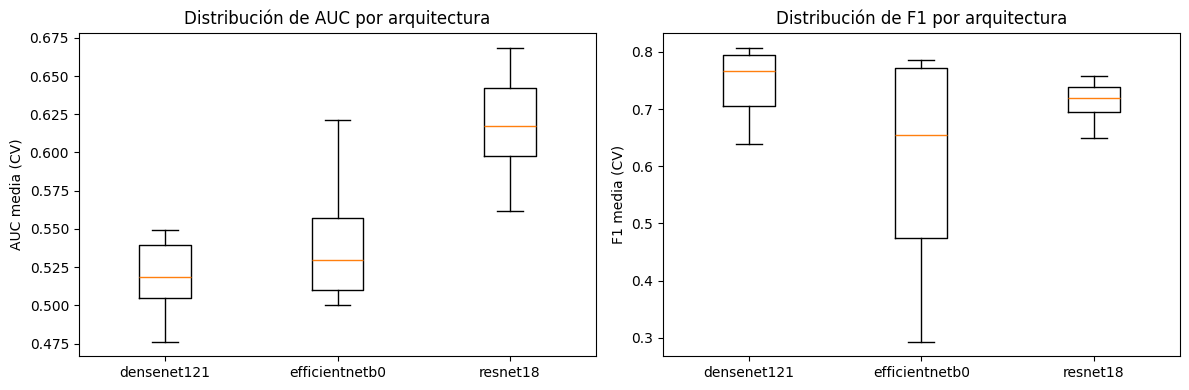

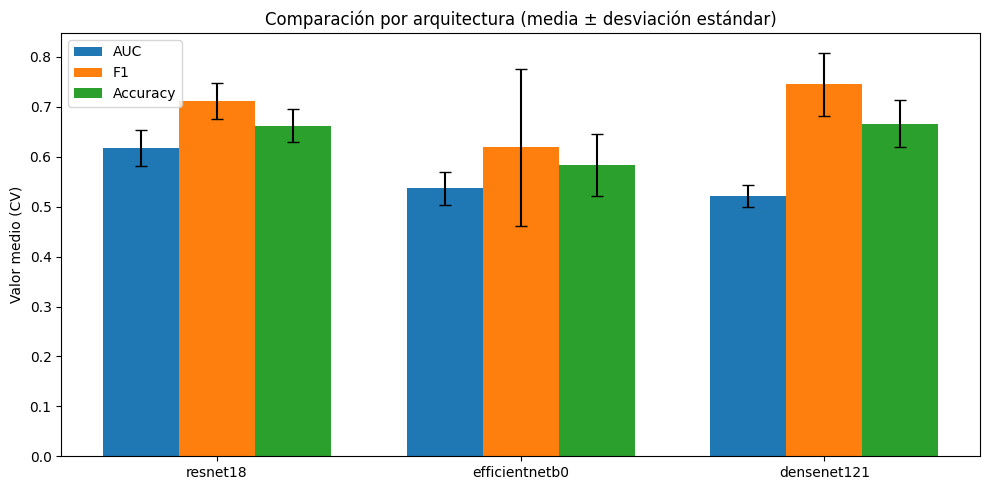

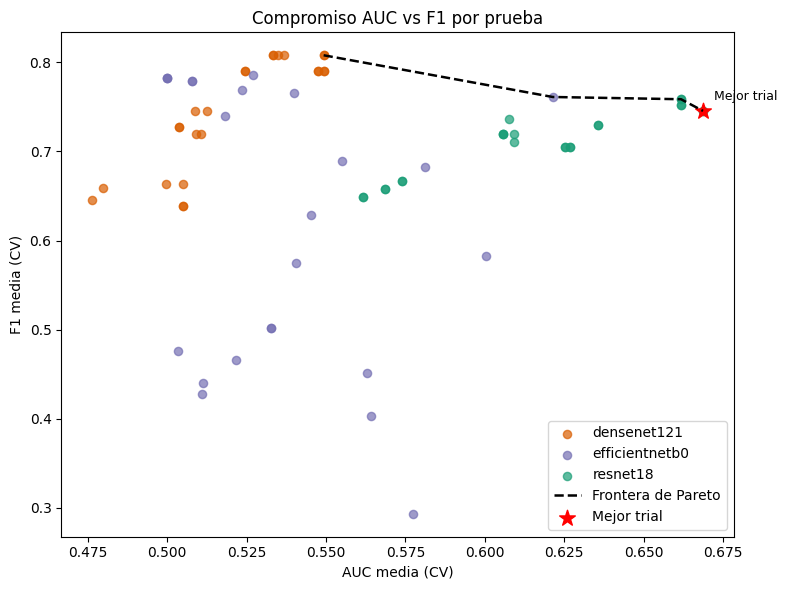

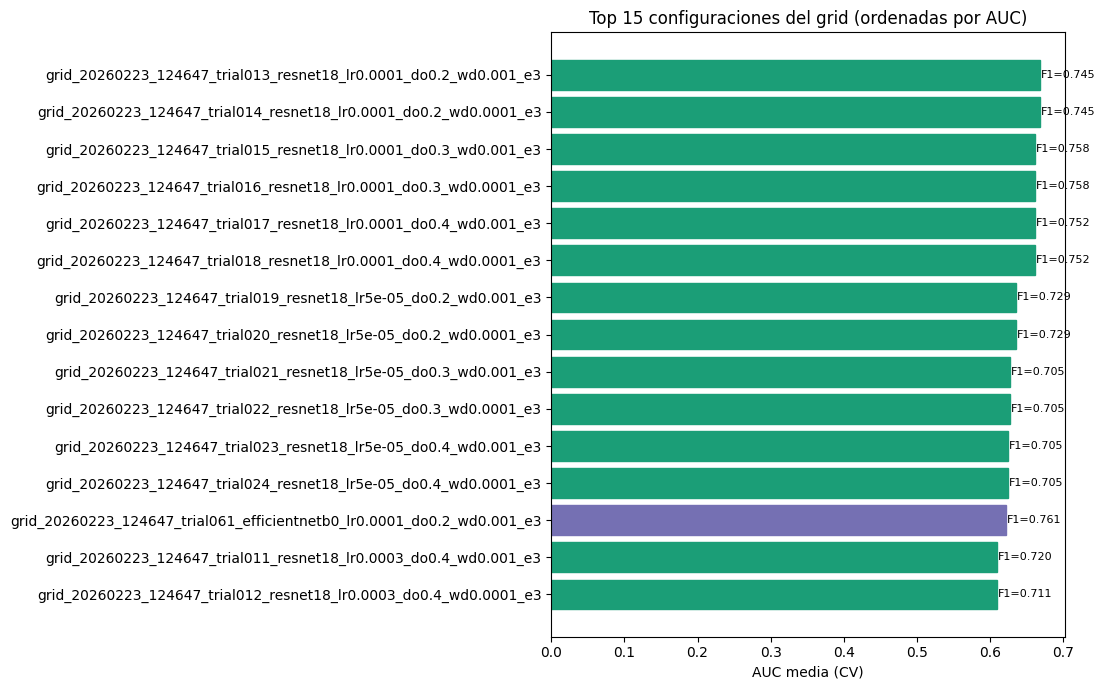


Archivos generados:
- G:\My Drive\Educacion\U de los Andes\MAIA\IV\Proyecto - Desarrollo de Soluciones\Micro-proyecto\maia_proyecto_desarrollo_soluciones\outputs\hiatal_grid_search\figures\grid_boxplots_auc_f1_por_arquitectura.png
- G:\My Drive\Educacion\U de los Andes\MAIA\IV\Proyecto - Desarrollo de Soluciones\Micro-proyecto\maia_proyecto_desarrollo_soluciones\outputs\hiatal_grid_search\figures\grid_barras_media_desviacion_auc_f1_accuracy.png
- G:\My Drive\Educacion\U de los Andes\MAIA\IV\Proyecto - Desarrollo de Soluciones\Micro-proyecto\maia_proyecto_desarrollo_soluciones\outputs\hiatal_grid_search\figures\grid_scatter_auc_vs_f1_pareto.png
- G:\My Drive\Educacion\U de los Andes\MAIA\IV\Proyecto - Desarrollo de Soluciones\Micro-proyecto\maia_proyecto_desarrollo_soluciones\outputs\hiatal_grid_search\figures\grid_top15_auc_con_f1.png
- G:\My Drive\Educacion\U de los Andes\MAIA\IV\Proyecto - Desarrollo de Soluciones\Micro-proyecto\maia_proyecto_desarrollo_soluciones\outputs\hiatal_gri

In [23]:
# Etapa 7) Comparación y figuras estándar para reporte académico
# Genera gráficos directamente desde grid_results.csv (fuente principal del grid).

ruta_grid = RUTA_SALIDA / 'grid_results.csv'
ruta_figuras = RUTA_SALIDA / 'figures'
ruta_figuras.mkdir(parents=True, exist_ok=True)

df_cmp = pd.read_csv(ruta_grid)
fuente = ruta_grid
print('Fuente de comparacion:', fuente)

# Orden de trabajo por AUC/F1 (criterio académico usual en clasificación binaria).
df_cmp = df_cmp.sort_values(['auc_mean', 'f1_mean'], ascending=False).reset_index(drop=True)

# Vista rápida top-15
print('Mejores resultados (15 primeros):')
cols_show = ['trial_name', 'run_name', 'arquitectura', 'lr', 'epocas', 'auc_mean', 'f1_mean', 'accuracy_mean']
cols_show = [c for c in cols_show if c in df_cmp.columns]
print(df_cmp[cols_show].head(15).to_string(index=False))

# -------- Figura 1: Boxplots AUC/F1 por arquitectura --------
archs = sorted(df_cmp['arquitectura'].dropna().unique().tolist())
data_auc = [df_cmp.loc[df_cmp['arquitectura'] == a, 'auc_mean'].dropna().values for a in archs]
data_f1 = [df_cmp.loc[df_cmp['arquitectura'] == a, 'f1_mean'].dropna().values for a in archs]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(data_auc, tick_labels=archs, showfliers=True)
axes[0].set_title('Distribución de AUC por arquitectura')
axes[0].set_ylabel('AUC media (CV)')

axes[1].boxplot(data_f1, tick_labels=archs, showfliers=True)
axes[1].set_title('Distribución de F1 por arquitectura')
axes[1].set_ylabel('F1 media (CV)')

plt.tight_layout()
ruta_fig1 = ruta_figuras / 'grid_boxplots_auc_f1_por_arquitectura.png'
fig.savefig(ruta_fig1, dpi=220)
plt.show()
plt.close(fig)

# -------- Figura 2: Media +/- desviacion (AUC/F1/Accuracy) --------
df_arch = (
    df_cmp.groupby('arquitectura')[['auc_mean', 'f1_mean', 'accuracy_mean']]
    .agg(['mean', 'std'])
    .reset_index()
)
# Aplana columnas multiindice de forma estable
df_arch.columns = [
    'arquitectura',
    'auc_mean', 'auc_std',
    'f1_mean', 'f1_std',
    'accuracy_mean', 'accuracy_std',
]
df_arch = df_arch.sort_values('auc_mean', ascending=False).reset_index(drop=True)

x = np.arange(len(df_arch))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, df_arch['auc_mean'], yerr=df_arch['auc_std'], width=w, capsize=4, label='AUC')
ax.bar(x, df_arch['f1_mean'], yerr=df_arch['f1_std'], width=w, capsize=4, label='F1')
ax.bar(x + w, df_arch['accuracy_mean'], yerr=df_arch['accuracy_std'], width=w, capsize=4, label='Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(df_arch['arquitectura'])
ax.set_ylabel('Valor medio (CV)')
ax.set_title('Comparación por arquitectura (media ± desviación estándar)')
ax.legend()
plt.tight_layout()
ruta_fig2 = ruta_figuras / 'grid_barras_media_desviacion_auc_f1_accuracy.png'
fig.savefig(ruta_fig2, dpi=220)
plt.show()
plt.close(fig)

# -------- Figura 3: Trade-off AUC vs F1 + frontera de Pareto --------
fig, ax = plt.subplots(figsize=(8, 6))

colores = {
    'resnet18': '#1b9e77',
    'densenet121': '#d95f02',
    'efficientnetb0': '#7570b3',
}

for a in archs:
    g = df_cmp[df_cmp['arquitectura'] == a]
    ax.scatter(g['auc_mean'], g['f1_mean'], s=35, alpha=0.7, label=a, color=colores.get(a, None))

# Frontera de Pareto (maximizar AUC y F1)
p = df_cmp.sort_values(['auc_mean', 'f1_mean'], ascending=[False, False]).reset_index(drop=True)
frontera = []
best_f1 = -np.inf
for _, r in p.iterrows():
    if r['f1_mean'] > best_f1:
        frontera.append(r)
        best_f1 = r['f1_mean']
if len(frontera) > 0:
    fr = pd.DataFrame(frontera).sort_values('auc_mean')
    ax.plot(fr['auc_mean'], fr['f1_mean'], '--', color='black', linewidth=1.8, label='Frontera de Pareto')

best = df_cmp.iloc[0]
ax.scatter([best['auc_mean']], [best['f1_mean']], marker='*', s=140, color='red', label='Mejor trial')
ax.annotate('Mejor trial', (best['auc_mean'], best['f1_mean']), xytext=(8, 8), textcoords='offset points', fontsize=9)

ax.set_xlabel('AUC media (CV)')
ax.set_ylabel('F1 media (CV)')
ax.set_title('Compromiso AUC vs F1 por prueba')
ax.legend(loc='lower right')
plt.tight_layout()
ruta_fig3 = ruta_figuras / 'grid_scatter_auc_vs_f1_pareto.png'
fig.savefig(ruta_fig3, dpi=220)
plt.show()
plt.close(fig)

# -------- Figura 4: Top-15 por AUC con etiqueta de F1 --------
top = df_cmp.head(15).copy().iloc[::-1]
top_label = top['trial_name'] if 'trial_name' in top.columns else top['run_name']

fig, ax = plt.subplots(figsize=(11, 7))
barras = ax.barh(top_label, top['auc_mean'])

# Color por arquitectura
if 'arquitectura' in top.columns:
    for b, a in zip(barras, top['arquitectura']):
        b.set_color(colores.get(a, '#4c72b0'))

for i, (_, r) in enumerate(top.iterrows()):
    ax.text(r['auc_mean'] + 0.001, i, f"F1={r['f1_mean']:.3f}", va='center', fontsize=8)

ax.set_xlabel('AUC media (CV)')
ax.set_title('Top 15 configuraciones del grid (ordenadas por AUC)')
plt.tight_layout()
ruta_fig4 = ruta_figuras / 'grid_top15_auc_con_f1.png'
fig.savefig(ruta_fig4, dpi=220)
plt.show()
plt.close(fig)

# Tabla de resumen por arquitectura para reporte
ruta_tabla = ruta_figuras / 'tabla_resumen_por_arquitectura.csv'
df_arch.to_csv(ruta_tabla, index=False)

print('')
print('Archivos generados:')
print('-', ruta_fig1)
print('-', ruta_fig2)
print('-', ruta_fig3)
print('-', ruta_fig4)
print('-', ruta_tabla)

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENTO)
with mlflow.start_run(run_name=f'{PREFIJO_RUN}_figuras_grid'):
    mlflow.set_tag('pipeline', 'grid_search_figuras')
    mlflow_log_artifactos_si_existe(ruta_fig1, carpeta_artifacto='figuras')
    mlflow_log_artifactos_si_existe(ruta_fig2, carpeta_artifacto='figuras')
    mlflow_log_artifactos_si_existe(ruta_fig3, carpeta_artifacto='figuras')
    mlflow_log_artifactos_si_existe(ruta_fig4, carpeta_artifacto='figuras')
    mlflow_log_artifactos_si_existe(ruta_tabla, carpeta_artifacto='figuras')
    mlflow_log_artifactos_si_existe(ruta_grid, carpeta_artifacto='salidas')

print('')
print('MLflow backend usado por este notebook:')
print(MLFLOW_TRACKING_URI)
print('Este notebook registra en servidor MLflow. Abre: http://localhost:8050/#/experiments')


<a id="etapa-8"></a>
## Etapa 8: Comparacion consolidada entre modelos entrenados

Compara curvas de entrenamiento y metricas OOF de `resnet18`, `efficientnetb0` y `densenet121` usando los artefactos ya generados en `outputs/`.

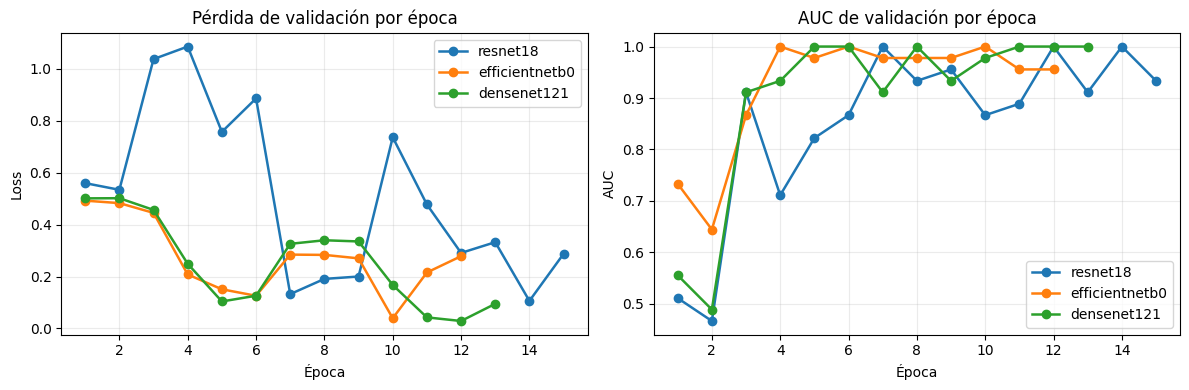

Resumen comparativo OOF:


,modelo,epocas,best_epoch_val_loss,best_val_loss,oof_auc,oof_f1,oof_accuracy,oof_sens,oof_spec
0,efficientnetb0,12,10,0.0392,0.9733,0.9556,0.9429,0.9556,0.92
1,densenet121,13,12,0.0287,0.9653,0.9213,0.9000,0.9111,0.88
2,resnet18,15,14,0.1061,0.9636,0.9333,0.9143,0.9333,0.88


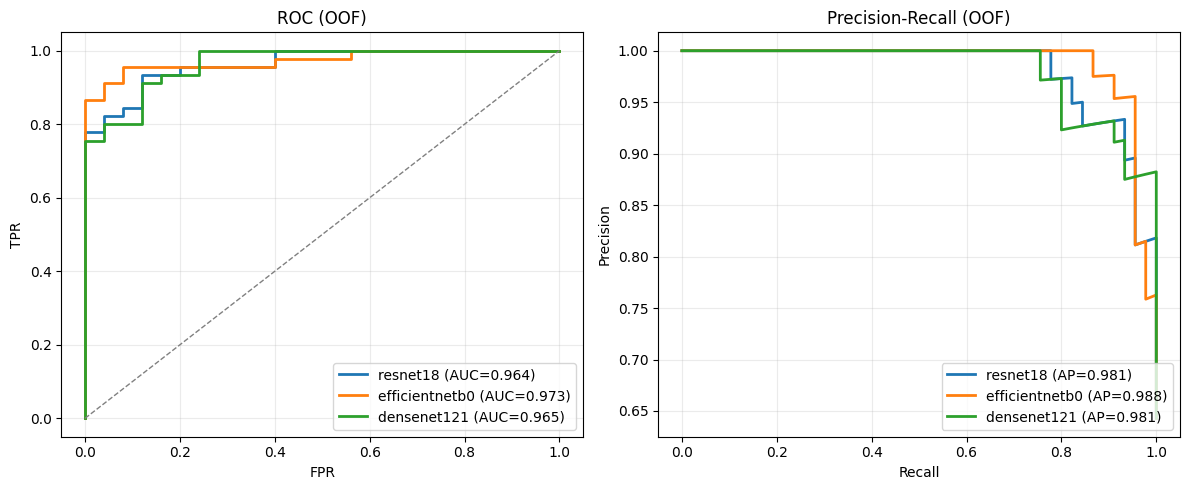

In [24]:
# Etapa 8) Reporte consolidado (curvas + OOF + ROC/PR)
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

base_out = RAIZ / 'outputs'
modelos_cmp = {
    'resnet18': {
        'hist': base_out / 'hiatal_notebook_resnet18' / 'historial_resnet_demo.csv',
        'oof': base_out / 'hiatal_notebook_resnet18' / 'oof_predictions.csv',
        'summary': base_out / 'hiatal_notebook_resnet18' / 'metrics_summary.json',
    },
    'efficientnetb0': {
        'hist': base_out / 'hiatal_notebook_efficientnetb0' / 'historial_efficientnetb0_demo.csv',
        'oof': base_out / 'hiatal_notebook_efficientnetb0' / 'oof_predictions.csv',
        'summary': base_out / 'hiatal_notebook_efficientnetb0' / 'metrics_summary.json',
    },
    'densenet121': {
        'hist': base_out / 'hiatal_notebook_densenet121' / 'historial_densenet_demo.csv',
        'oof': base_out / 'hiatal_notebook_densenet121' / 'oof_predictions.csv',
        'summary': base_out / 'hiatal_notebook_densenet121' / 'metrics_summary.json',
    },
}

historiales = {}
resumenes = {}
oof_data = {}

for nombre, cfg in modelos_cmp.items():
    historiales[nombre] = pd.read_csv(cfg['hist'])
    oof_data[nombre] = pd.read_csv(cfg['oof'])
    with open(cfg['summary'], 'r', encoding='utf-8') as f:
        resumenes[nombre] = json.load(f)

# Figura 1: Curvas comparadas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for nombre, df_h in historiales.items():
    axes[0].plot(df_h['epoca'], df_h['perdida_val'], marker='o', linewidth=1.8, label=nombre)
    axes[1].plot(df_h['epoca'], df_h['auc'], marker='o', linewidth=1.8, label=nombre)

axes[0].set_title('Pérdida de validación por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')

axes[1].set_title('AUC de validación por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('AUC')

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

# Tabla compacta de metricas OOF
filas = []
for nombre, df_h in historiales.items():
    idx_best_loss = df_h['perdida_val'].idxmin()
    oof_m = resumenes[nombre]['oof_metrics']
    filas.append({
        'modelo': nombre,
        'epocas': int(len(df_h)),
        'best_epoch_val_loss': int(df_h.loc[idx_best_loss, 'epoca']),
        'best_val_loss': float(df_h.loc[idx_best_loss, 'perdida_val']),
        'oof_auc': float(oof_m['auc']),
        'oof_f1': float(oof_m['f1']),
        'oof_accuracy': float(oof_m['accuracy']),
        'oof_sens': float(oof_m['sensibilidad']),
        'oof_spec': float(oof_m['especificidad']),
    })

tabla_cmp = pd.DataFrame(filas).sort_values('oof_auc', ascending=False).reset_index(drop=True)
print('Resumen comparativo OOF:')
display(tabla_cmp.round(4))

# Figura 2: ROC y PR comparadas con OOF
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for nombre, dfo in oof_data.items():
    y = dfo['label'].to_numpy(dtype=int)
    p = dfo['probability'].to_numpy(dtype=float)

    fpr, tpr, _ = roc_curve(y, p)
    precision, recall, _ = precision_recall_curve(y, p)

    auc = roc_auc_score(y, p)
    ap = average_precision_score(y, p)

    axes[0].plot(fpr, tpr, linewidth=2, label=f'{nombre} (AUC={auc:.3f})')
    axes[1].plot(recall, precision, linewidth=2, label=f'{nombre} (AP={ap:.3f})')

axes[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
axes[0].set_title('ROC (OOF)')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')

axes[1].set_title('Precision-Recall (OOF)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

